# 03 · Angle 1 — is the $42M a floor?

Finance published $42M of annual people cost, in three components with a
stated range each. Nobody has checked whether the headcount those ranges
imply matches the headcount actually in the HRIS.

The method is deliberately blunt: take Finance's *own* unit costs, divide the
published range by them to get an implied population, and compare against the
observed one. No new assumptions, so the gap cannot be argued away as a
modelling choice.

> Carry-forward from `02`: the attrition log reconciles to only ~60% of the
> annual report's FY2025 departures. Everything below is therefore a **lower
> bound**.

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys

_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "etl.py").exists())
sys.path.insert(0, str(_root / "src"))

from nbinit import *

df = load("analysis_df")

## 1. Finance's unit costs, restated

Each of these is the brief's own arithmetic — nothing here is our assumption.

In [2]:
unit = {
    "Regrettable attrition": etl.AR_AVG_BASE_SALARY * etl.REPLACEMENT_MULTIPLIER * etl.BACKFILL_RATE,
    "Disengagement": etl.AR_AVG_BASE_SALARY * etl.DISENGAGEMENT_LOSS,
    "Hiring inefficiency": etl.AR_AVG_BASE_SALARY * etl.AGENCY_FEE_RATE - etl.DIRECT_HIRE_BENCHMARK,
}

pd.DataFrame({
    "unit cost": pd.Series(unit).map("${:,.0f}".format),
    "derivation": [
        f"${etl.AR_AVG_BASE_SALARY:,.0f} x {etl.REPLACEMENT_MULTIPLIER} x {etl.BACKFILL_RATE} backfill",
        f"${etl.AR_AVG_BASE_SALARY:,.0f} x {pct(etl.DISENGAGEMENT_LOSS, 0)} productivity loss",
        f"${etl.AR_AVG_BASE_SALARY:,.0f} x {pct(etl.AGENCY_FEE_RATE, 0)} agency fee - ${etl.DIRECT_HIRE_BENCHMARK:,.0f} direct benchmark",
    ],
})

,unit cost,derivation
Regrettable attrition,"$163,200","$128,000 x 1.5 x 0.85 backfill"
Disengagement,"$19,200","$128,000 x 15% productivity loss"
Hiring inefficiency,"$17,540","$128,000 x 18% agency fee - $5,500 direct benc..."


## 2. Implied population vs observed population

The three counts below are the judgement calls in this notebook, so they are
stated plainly rather than buried in a helper:

- **Regrettable attrition** — HR's own `regrettable_flag`. Section 4 revisits
  what happens if you use an evidence-based definition instead.
- **Disengagement** — employees with a composite score below 3.0 in two or
  more waves they actually answered. Section 5 sensitivity-tests both numbers.
- **Hiring inefficiency** — employees sourced through an agency.

In [3]:
observed = {
    "Regrettable attrition": int(df["regrettable_hr"].sum()),
    "Disengagement": int(df["persistently_disengaged"].fillna(False).sum()),
    "Hiring inefficiency": int(df["hire_source"].eq("agency").sum()),
}

bridge = pd.DataFrame([
    {
        "component": label,
        "finance_low_$m": lo / 1e6,
        "finance_high_$m": hi / 1e6,
        "unit_cost_$": round(unit[label]),
        "implied_n_low": int(lo / unit[label]),
        "implied_n_high": int(hi / unit[label]),
        "observed_n": observed[label],
        "observed_cost_$m": round(observed[label] * unit[label] / 1e6, 1),
    }
    for label, (lo, hi) in zip(observed, etl.COST_COMPONENTS.values())
])
bridge["multiple_of_high"] = (bridge["observed_n"] / bridge["implied_n_high"]).round(1)
bridge

,component,finance_low_$m,finance_high_$m,unit_cost_$,implied_n_low,implied_n_high,observed_n,observed_cost_$m,multiple_of_high
0,Regrettable attrition,22.00,25.00,163200,134,153,153,25.00,1.00
1,Disengagement,12.00,15.00,19200,625,781,3219,61.80,4.10
2,Hiring inefficiency,4.00,6.00,17540,228,342,3243,56.90,9.50


In [4]:
total = bridge["observed_cost_$m"].sum()
print(f"  Finance published        : $42.0M   (range $38–46M)")
print(f"  Same unit costs, our data: ${total:.1f}M")
print(f"  Gap                      : ${total - 42:+.1f}M   ({total / 42:.1f}x)")

  Finance published        : $42.0M   (range $38–46M)
  Same unit costs, our data: $143.7M
  Gap                      : $+101.7M   (3.4x)


## 3. The chart

One row per component, in dollars — the only unit that makes the three
comparable. The bar is Finance's published range; the dot is what their own
arithmetic produces when applied to the actual population.

  saved figures\a1_cost_bridge.png


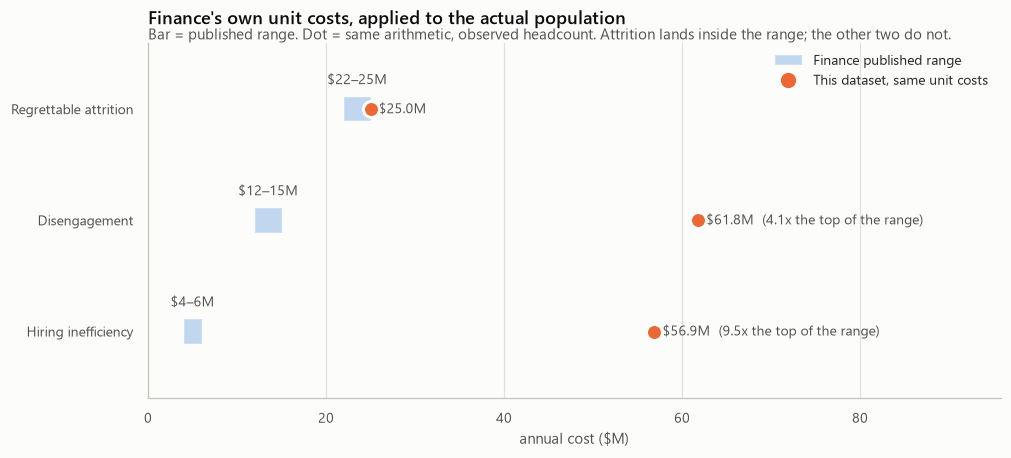

In [5]:
fig, ax = figure(
    "Finance's own unit costs, applied to the actual population",
    "Bar = published range. Dot = same arithmetic, observed headcount. "
    "Attrition lands inside the range; the other two do not.",
    figsize=(10, 4.2),
)

y = np.arange(len(bridge))[::-1]
ax.barh(y, bridge["finance_high_$m"] - bridge["finance_low_$m"],
        left=bridge["finance_low_$m"], height=0.22,
        color=SERIES[0], alpha=0.28, zorder=2)
ax.scatter(bridge["observed_cost_$m"], y, s=110, color=SERIES[1], zorder=4,
           edgecolor=INK["surface"], linewidth=2, label="observed")

for yi, (_, row) in zip(y, bridge.iterrows()):
    ax.annotate(f"${row['finance_low_$m']:.0f}–{row['finance_high_$m']:.0f}M",
                xy=((row["finance_low_$m"] + row["finance_high_$m"]) / 2, yi + 0.20),
                ha="center", va="bottom", fontsize=9, color=INK["secondary"])
    ax.annotate(f"  ${row['observed_cost_$m']:.1f}M  ({row['multiple_of_high']:.1f}x the top of the range)"
                if row["multiple_of_high"] > 1.05 else f"  ${row['observed_cost_$m']:.1f}M",
                xy=(row["observed_cost_$m"], yi), va="center",
                fontsize=9, color=INK["secondary"])

ax.set_yticks(y, bridge["component"])
ax.set(xlabel="annual cost ($M)", ylim=(-0.6, len(bridge) - 0.4),
       xlim=(0, bridge["observed_cost_$m"].max() * 1.55))
ax.grid(axis="x", zorder=0)
ax.grid(axis="y", visible=False)
ax.legend(handles=[
    Patch(facecolor=SERIES[0], alpha=0.28, label="Finance published range"),
    Line2D([], [], marker="o", ls="", color=SERIES[1], markersize=9,
           label="This dataset, same unit costs"),
], loc="upper right")
save_fig(fig, "a1_cost_bridge")
plt.show()

### What this says

Regrettable attrition lands **inside** Finance's range — their model is not
broken. The other two components are out by multiples, and the reason is the
same in both cases: Finance sized them from a rate, and the data has a
population.

The framing for the deck is not "Finance got it wrong." It is: *the $42M
counts the departures it can see. It does not count the people who are still
here and disengaged, or the premium being paid to replace them.*

## 4. Who counts as regrettable?

HR's `regrettable_flag` is applied retrospectively, by the exiting manager,
at the point of exit. An evidence-based alternative: a voluntary departure by
someone flagged high-potential **or** rated High Performer / Outstanding at
their last review.

In [6]:
overlap = pd.crosstab(
    df["regrettable_hr"].map({True: "HR: regrettable", False: "HR: not regrettable"}),
    df["regrettable_evidence"].map({True: "Evidence: regrettable", False: "Evidence: not"}),
)
overlap

regrettable_evidence,Evidence: not,Evidence: regrettable
regrettable_hr,,
HR: not regrettable,12855,395
HR: regrettable,52,101


In [7]:
hr_n = int(df["regrettable_hr"].sum())
ev_n = int(df["regrettable_evidence"].sum())
both = int((df["regrettable_hr"] & df["regrettable_evidence"]).sum())

print(f"  Flagged by HR                     : {hr_n:,}")
print(f"  Meet the evidence-based test      : {ev_n:,}")
print(f"  Both                              : {both:,}")
print(f"  HR captures {100 * both / ev_n:.0f}% of the evidence-based set")
print(f"\n  Cost at Finance's unit rate:")
print(f"    on HR's definition       : {millions(hr_n * unit['Regrettable attrition'])}")
print(f"    on the evidence test     : {millions(ev_n * unit['Regrettable attrition'])}")
print(f"    difference               : {millions((ev_n - hr_n) * unit['Regrettable attrition'])}")

  Flagged by HR                     : 153
  Meet the evidence-based test      : 496
  Both                              : 101
  HR captures 20% of the evidence-based set

  Cost at Finance's unit rate:
    on HR's definition       : $25.0M
    on the evidence test     : $80.9M
    difference               : $56.0M


In [8]:
missed = df[df["regrettable_evidence"] & ~df["regrettable_hr"]]

print(f"  {len(missed):,} voluntary exits by high-potential or high-performing staff")
print(f"  that HR did not flag as regrettable.\n")
print("  Where they went, by stated reason:")
print(missed["stated_exit_reason"].value_counts().head(8).to_string())

  395 voluntary exits by high-potential or high-performing staff
  that HR did not flag as regrettable.

  Where they went, by stated reason:
stated_exit_reason
Career advancement                   224
Better opportunity                    98
Compensation                          18
Personal reasons                      15
Relocation                            13
Work-life balance                     12
Role uncertainty / unclear future      8
Study/career change                    7


  saved figures\a1_regrettable_definitions.png


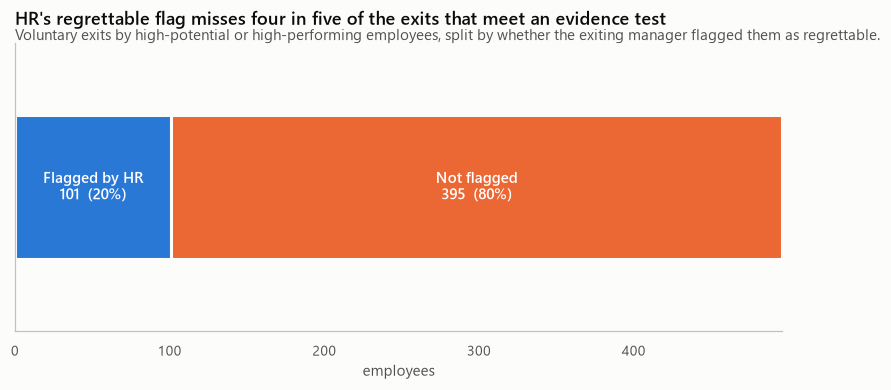

In [9]:
fig, ax = figure(
    "HR's regrettable flag misses four in five of the exits that meet an evidence test",
    "Voluntary exits by high-potential or high-performing employees, "
    "split by whether the exiting manager flagged them as regrettable.",
    figsize=(9, 3.4),
)

segments = [("Flagged by HR", both, SERIES[0]),
            ("Not flagged", ev_n - both, SERIES[1])]
left = 0
for label, value, colour in segments:
    ax.barh([0], [value], left=left, height=0.5, color=colour,
            edgecolor=INK["surface"], linewidth=2)
    ax.annotate(f"{label}\n{value:,}  ({100 * value / ev_n:.0f}%)",
                xy=(left + value / 2, 0), ha="center", va="center",
                fontsize=10, color="white", fontweight="600")
    left += value

ax.set(xlim=(0, ev_n), ylim=(-0.5, 0.5), xlabel="employees")
ax.set_yticks([])
ax.grid(visible=False)
save_fig(fig, "a1_regrettable_definitions")
plt.show()

## 5. Sensitivity — do the conclusions survive the judgement calls?

Two thresholds were chosen by us, not by the brief: the disengagement score
cut-off (3.0) and how many low waves count as *persistent* (2). If the
headline flips under a reasonable alternative, it is not a finding.

In [10]:
eng_long = load("engagement_long")
answered = eng_long[eng_long["responded"]]

rows = []
for score_cut in [2.5, 2.75, 3.0, 3.25, 3.5]:
    low = answered[answered["composite"] < score_cut]
    counts = low.groupby("employee_id", observed=True).size()
    for wave_cut in [1, 2, 3]:
        n = int((counts >= wave_cut).sum())
        rows.append({
            "score_cut": score_cut,
            "min_low_waves": wave_cut,
            "employees": n,
            "cost_$m": round(n * unit["Disengagement"] / 1e6, 1),
        })

sens = pd.DataFrame(rows)
sens.pivot(index="score_cut", columns="min_low_waves", values="cost_$m")

min_low_waves,1,2,3
score_cut,,,
2.50,28.10,17.10,10.90
2.75,52.80,34.20,23.20
3.00,87.70,61.80,44.30
3.25,126.80,95.40,71.80
3.50,165.30,131.20,104.00


  saved figures\a1_sensitivity.png


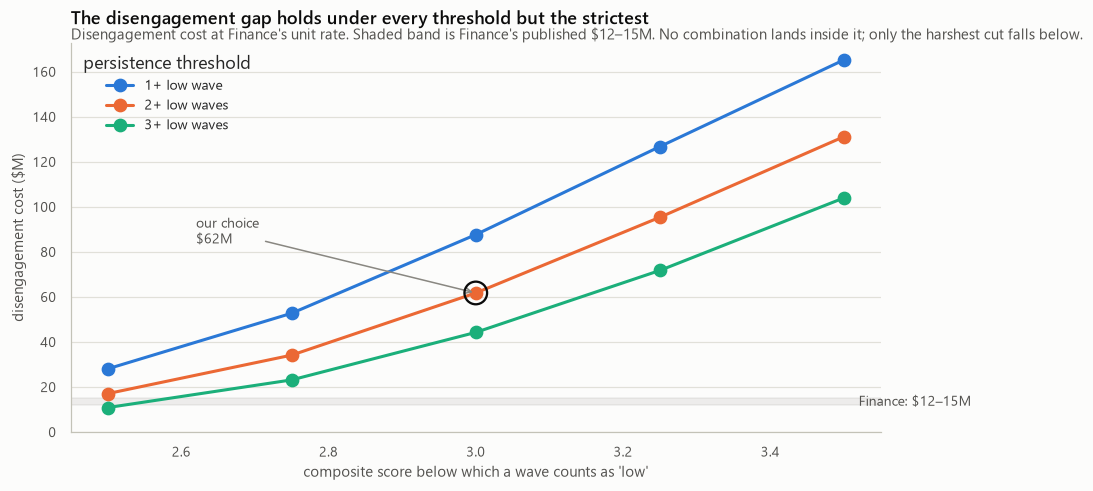

In [11]:
fig, ax = figure(
    "The disengagement gap holds under every threshold but the strictest",
    "Disengagement cost at Finance's unit rate. Shaded band is Finance's published "
    "$12–15M. No combination lands inside it; only the harshest cut falls below.",
    figsize=(9.5, 4.6),
)

ax.axhspan(12, 15, color=INK["muted"], alpha=0.13, zorder=0)
ax.annotate("Finance: $12–15M", xy=(3.52, 13.5), va="center",
            fontsize=9, color=INK["secondary"])

for i, wave_cut in enumerate([1, 2, 3]):
    sub = sens[sens["min_low_waves"] == wave_cut]
    ax.plot(sub["score_cut"], sub["cost_$m"], color=SERIES[i], marker="o",
            label=f"{wave_cut}+ low wave{'s' if wave_cut > 1 else ''}")

chosen = sens.query("score_cut == 3.0 and min_low_waves == 2").iloc[0]
ax.scatter([3.0], [chosen["cost_$m"]], s=220, facecolor="none",
           edgecolor=INK["primary"], linewidth=1.5, zorder=5)
ax.annotate(f"our choice\n${chosen['cost_$m']:.0f}M", xy=(3.0, chosen["cost_$m"]),
            xytext=(2.62, chosen["cost_$m"] + 22), fontsize=9, color=INK["secondary"],
            arrowprops=dict(arrowstyle="->", color=INK["muted"], lw=1))

ax.set(xlabel="composite score below which a wave counts as 'low'",
       ylabel="disengagement cost ($M)", ylim=(0, None))
ax.legend(title="persistence threshold", loc="upper left")
save_fig(fig, "a1_sensitivity")
plt.show()

## 6. Where the cost concentrates

A total is not actionable. This is the cut that turns the number into a
recommendation.

In [12]:
departed = df[df["is_departed"] & df["is_voluntary"]]

by_dept = departed.groupby("department", observed=True).agg(
    exits=("employee_id", "size"),
    regrettable=("regrettable_hr", "sum"),
    replacement_cost=("replacement_cost", "sum"),
).sort_values("replacement_cost", ascending=False)
by_dept["cost_$m"] = (by_dept["replacement_cost"] / 1e6).round(1)
by_dept["share_of_cost"] = (100 * by_dept["replacement_cost"] / by_dept["replacement_cost"].sum()).round(1)
by_dept["regrettable_pct"] = (100 * by_dept["regrettable"] / by_dept["exits"]).round(1)
by_dept[["exits", "regrettable", "regrettable_pct", "cost_$m", "share_of_cost"]]

,exits,regrettable,regrettable_pct,cost_$m,share_of_cost
department,,,,,
Retail Banking,252,23,9.10,39.80,22.10
Technology,257,31,12.10,38.90,21.60
Risk & Compliance,195,33,16.90,32.60,18.00
Corporate Operations,146,25,17.10,23.50,13.00
Insurance,143,24,16.80,22.60,12.50
Wealth Management,123,15,12.20,20.30,11.20
Executive Leadership,17,2,11.80,2.70,1.50


  saved figures\a1_cost_by_department.png


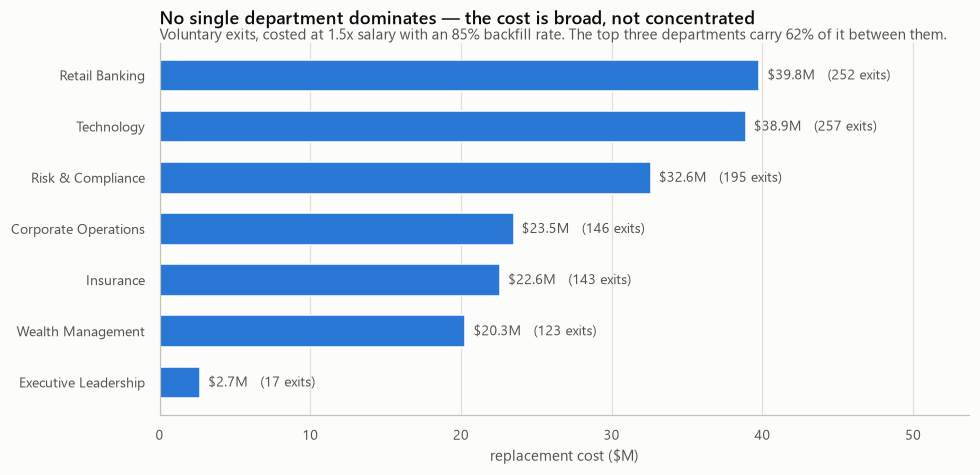

In [13]:
top3 = by_dept["share_of_cost"].head(3).sum()

fig, ax = figure(
    "No single department dominates — the cost is broad, not concentrated",
    f"Voluntary exits, costed at 1.5x salary with an 85% backfill rate. "
    f"The top three departments carry {top3:.0f}% of it between them.",
    figsize=(9.5, 4.4),
)

order = by_dept.sort_values("cost_$m")
bars = ax.barh(order.index, order["cost_$m"], height=0.62, color=SERIES[0])
for bar, (_, row) in zip(bars, order.iterrows()):
    ax.annotate(f"  ${row['cost_$m']:.1f}M   ({row['exits']:,} exits)",
                xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                va="center", fontsize=9, color=INK["secondary"])

ax.set(xlabel="replacement cost ($M)", xlim=(0, order["cost_$m"].max() * 1.35))
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
save_fig(fig, "a1_cost_by_department")
plt.show()

**Volume is the wrong cut.** The cost is spread across seven departments in
rough proportion to their size, which makes "target the worst department" a
recommendation with nowhere to point.

The cut that does discriminate is *quality* of exit. Risk & Compliance loses
fewer people than Retail Banking or Technology but flags a far higher share
of them as regrettable — and it is also the population Angle 2 is about.
That is where a retention budget goes.

In [14]:
quality = by_dept.loc[by_dept["exits"] >= 100, ["exits", "regrettable", "regrettable_pct"]]
quality.sort_values("regrettable_pct", ascending=False)

,exits,regrettable,regrettable_pct
department,,,
Corporate Operations,146,25,17.10
Risk & Compliance,195,33,16.90
Insurance,143,24,16.80
Wealth Management,123,15,12.20
Technology,257,31,12.10
Retail Banking,252,23,9.10


## The Angle 1 story

1. **Finance's attrition model is sound** — apply their unit cost to the
   observed regrettable departures and you land inside their own range.
2. **The $42M is a floor, on three independent counts:**
   the attrition log reconciles to only ~60% of the annual report's FY2025
   departures (`02`); the disengaged population is several times the size the
   $12–15M band implies; and agency hiring is running at a multiple of the
   volume behind the $4–6M band.
3. **The definition of "regrettable" is doing real work.** HR's flag captures
   only a fifth of the voluntary exits by high-potential or high-performing
   staff — 395 of them were never flagged, and the modal stated reason is
   "career advancement". That is not a costing error, it is a measurement
   gap, and it is the one HR can fix on Monday.

### The number to defend

Not the $143.7M — that total inherits our disengagement threshold, and
section 5 shows it moving between $28M and $165M across defensible cuts.
Defend the **direction and the mechanism**: Finance's own arithmetic, applied
to the observed population, cannot land inside their published range for two
of three components, and every source of error identified in `02` pushes the
same way.